# Overall picture: RAMIP, ScenarioMIP, overshoot

Pulls together everything the other notebooks cached into the summary tables and figures a reader
would actually want: what data exists, when each experiment reaches each warming level, how the
regional temperature and precipitation responses look, and where path-independence does or does
not hold once global warming is matched.

Reads only caches — nothing here recomputes a KS test. Sections whose inputs are missing are
skipped with a printed note rather than failing, so this runs while other jobs are still going.

**Companion notebooks**: `ramip_data_layer.ipynb` (GMST, crossings, regional means),
`ks_path_independence_ramip_gwl.ipynb` (`tas` at GWL2.0), `ks_path_independence_ramip_gwl_vars.ipynb`
(`pr`/`tasmax`/`tasmin`), `ks_location_scenarios.ipynb` (SSP pairs, overshoot, multi-GWL),
`ramip_impacts_gdp.ipynb` (Burke growth response).

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import regionmask

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/path_independence')
from funcs_support import get_params
import ks_tools as kt
dir_list = get_params()
warnings.filterwarnings('ignore', category=FutureWarning)

DL_DIR  = dir_list['aux'] + 'data_layer/'
REG_DIR = DL_DIR + 'regional/'
GWL_DIR = dir_list['aux'] + 'diagnostics/ramip_gwl/'
SCEN_KS = dir_list['aux'] + 'diagnostics/ks_scenarios/'
IMP_DIR = dir_list['aux'] + 'diagnostics/impacts/'
out_dir = dir_list['aux'] + '../figures/'
SUM_DIR = dir_list['aux'] + 'summary/'
os.makedirs(SUM_DIR, exist_ok=True)

GWL, ALPHA, FLOOR = 2.0, 0.05, 0.057
VARS  = ['tas', 'pr', 'tasmax', 'tasmin']
ANCHOR = {'CESM2': 'ssp370-LE'}
OTHER  = 'ssp370-126aer'


def anchor(mod):
    return ANCHOR.get(mod, 'ssp370')


gm    = pd.read_csv(DL_DIR + 'gmst_annual_long.csv')
cross = pd.read_csv(DL_DIR + 'gwl_crossings.csv')
MODELS = sorted(gm.model.unique())
print(f'{len(MODELS)} models, {gm.exp.nunique()} experiments, {len(gm)} model-run-years')

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


9 models, 11 experiments, 31787 model-run-years


## Table 1 — what data exists

Members per (model, experiment) for the RAMIP archive, and the same for the ScenarioMIP /
overshoot download. This is the table to check before believing any multi-model number below:
several results rest on 6 members, not 10.

In [2]:
t1 = gm.groupby(['model', 'exp']).run.nunique().unstack(fill_value=0)
t1.to_csv(SUM_DIR + 'table1_ramip_members.csv')
print('RAMIP members per experiment')
print(t1.to_string())

scen_inv = DL_DIR + 'scenariomip_inventory.csv'
if os.path.exists(SCEN_KS + '../../data_layer/scenariomip_gmst_annual.csv'):
    sgm = pd.read_csv(DL_DIR + 'scenariomip_gmst_annual.csv')
    t1b = sgm.groupby(['model', 'exp']).run.nunique().unstack(fill_value=0)
    t1b.to_csv(SUM_DIR + 'table1b_scenariomip_members.csv')
    print('\nScenarioMIP / overshoot members per experiment (tas)')
    print(t1b.to_string())
else:
    print('\n(scenariomip GMST cache not written yet)')

RAMIP members per experiment
exp                ssp370  ssp370-126aer  ssp370-AFR126aer  ssp370-ASIA126aer  ssp370-EAS126aer  ssp370-LE  ssp370-NAE126aer  ssp370-SAF126ca  ssp370-SAS126aer  ssp370-SAS126ca  ssp370-ramip
model                                                                                                                                                                                         
CESM2                   0             10                10                  0                10         10                10                0                10                0             0
CNRM-ESM2-1            10             10                10                 10                10          0                10               10                10               10             0
CanESM5-1              10             10                10                  0                10          0                10                0                10                0             0
EC-Earth3-AerChe

## Table 2 — when each experiment reaches each warming level

Median over runs of the last year of the first 10-yr window reaching the level. Blank = the
experiment never gets there inside its available record. The `126aer − ssp370` column is the
warming *acceleration* from removing aerosols: the reason a year-matched comparison of the two
arms is not a comparison at equal warming.

In [3]:
main = cross[cross.exp.isin(['ssp370', 'ssp370-LE', OTHER])]
t2 = (main.groupby(['model', 'exp', 'gwl']).window_end.median().unstack('exp'))
t2['anchor'] = t2.get('ssp370')
if 'ssp370-LE' in t2:
    t2['anchor'] = t2['anchor'].fillna(t2['ssp370-LE'])
t2['lead_yr'] = t2['anchor'] - t2[OTHER]
t2 = t2[['anchor', OTHER, 'lead_yr']].rename(columns={OTHER: '126aer'})
t2.to_csv(SUM_DIR + 'table2_gwl_crossings.csv')
print('median GWL crossing year (window end), anchor vs 126aer, and the aerosol lead in years')
print(t2.round(1).to_string())

median GWL crossing year (window end), anchor vs 126aer, and the aerosol lead in years
exp                    anchor  126aer  lead_yr
model             gwl                         
CESM2             1.5  2033.0  2027.5      5.5
                  2.0  2046.0  2037.0      9.0
                  2.5  2058.5  2047.0     11.5
                  3.0  2071.0  2056.5     14.5
CNRM-ESM2-1       1.5  2042.0  2038.0      4.0
                  2.0  2055.0  2048.0      7.0
                  2.5  2065.0     NaN      NaN
                  3.0  2074.5     NaN      NaN
CanESM5-1         1.5  2024.0  2024.0      0.0
                  2.0  2027.0  2026.5      0.5
                  2.5  2038.0  2035.5      2.5
                  3.0  2047.0  2044.5      2.5
EC-Earth3-AerChem 1.5  2033.5  2029.0      4.5
                  2.0  2041.5  2034.5      7.0
                  2.5  2050.0  2042.0      8.0
                  3.0     NaN  2049.0      NaN
GISS-E2-1-G       1.5  2026.0  2025.5      0.5
                  2.

## Figure 1 — GMST trajectories with the GWL2.0 windows

The whole design in one panel per model: both global arms, the regional-cleanup arms in grey, and
the warming levels. Where the two coloured bundles separate is exactly the offset that GWL
matching removes.

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/summary_fig1_gmst.png


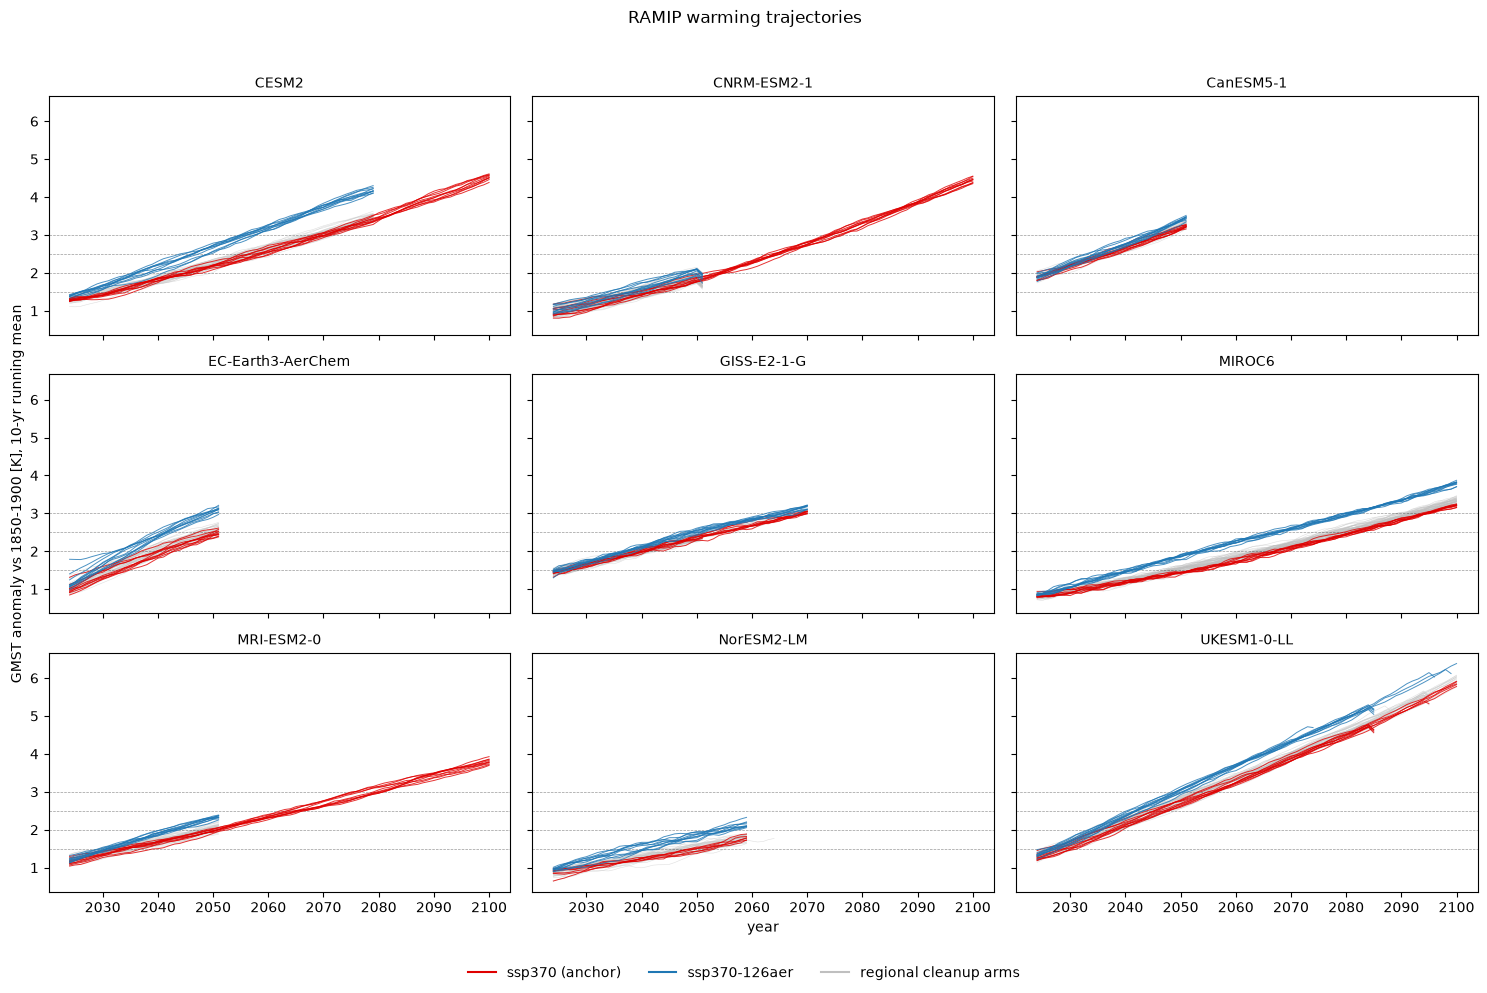

In [4]:
fig, axs = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)
for ax, mod in zip(axs.flat, MODELS):
    sub = gm[gm.model == mod]
    for exp, se in sub.groupby('exp'):
        piv = se.pivot_table(index='year', columns='run', values='gmst_anom').rolling(10).mean()
        if exp in (anchor(mod),):
            ax.plot(piv.index, piv.values, color='#df0000', lw=0.7, alpha=0.8, zorder=3)
        elif exp == OTHER:
            ax.plot(piv.index, piv.values, color='#1f77b4', lw=0.7, alpha=0.8, zorder=3)
        else:
            ax.plot(piv.index, piv.values, color='0.75', lw=0.4, alpha=0.5, zorder=1)
    for g in [1.5, 2.0, 2.5, 3.0]:
        ax.axhline(g, color='k', ls='--', lw=0.5, alpha=0.4)
    ax.set_title(mod, fontsize=10)
axs[1, 0].set_ylabel('GMST anomaly vs 1850-1900 [K], 10-yr running mean')
axs[2, 1].set_xlabel('year')
handles = [plt.Line2D([], [], color=c, label=l) for c, l in
           [('#df0000', 'ssp370 (anchor)'), ('#1f77b4', OTHER), ('0.75', 'regional cleanup arms')]]
fig.legend(handles=handles, ncol=3, loc='lower center', frameon=False)
fig.suptitle('RAMIP warming trajectories', y=0.98)
fig.tight_layout(rect=[0, 0.04, 1, 0.96])
fig.savefig(out_dir + 'summary_fig1_gmst.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'summary_fig1_gmst.png')

## Table 3 + Figure 2 — path-independence across variables

Land fraction of pixels rejecting at α=0.05 with the block-permutation test, `ssp370` vs
`ssp370-126aer` sampled at each arm's own GWL2.0 decade. The line to compare against is the
test's own false-positive rate on same-forcing ensemble pairs, **0.057** — not zero.

In [5]:
rows = []
for var in VARS:
    d = f'{GWL_DIR}ks/' if var == 'tas' else f'{GWL_DIR}ks_{var}/'
    for fn in sorted(glob.glob(d + '*.nc')):
        ds = xr.open_dataset(fn).load()
        rows.append({'model': os.path.basename(fn)[:-3], 'var': var,
                     'n_runs': ds.sizes['run'], 'land_frac': kt.land_fraction(ds, 'run', ALPHA)})
t3 = pd.DataFrame(rows).pivot(index='model', columns='var', values='land_frac')[VARS]
t3['n_runs'] = pd.DataFrame(rows).groupby('model').n_runs.max()
t3.loc['multi-model mean'] = t3.mean()
t3.to_csv(SUM_DIR + 'table3_landfrac_by_var.csv')
print(f'land fraction rejecting at alpha={ALPHA}, GWL{GWL}-matched (floor {FLOOR})')
print(t3.round(3).to_string())

land fraction rejecting at alpha=0.05, GWL2.0-matched (floor 0.057)
var                  tas     pr  tasmax  tasmin  n_runs
model                                                  
CESM2              0.069  0.045   0.047   0.067    10.0
CNRM-ESM2-1        0.049  0.044   0.050   0.049     6.0
CanESM5-1          0.040  0.049   0.044   0.036    10.0
EC-Earth3-AerChem  0.071  0.062   0.069   0.053     6.0
GISS-E2-1-G        0.045  0.048   0.046   0.044    10.0
MIROC6             0.066  0.050   0.075   0.052    10.0
MRI-ESM2-0         0.054  0.056   0.059   0.051    10.0
UKESM1-0-LL        0.066  0.044   0.061   0.060    10.0
multi-model mean   0.058  0.050   0.056   0.052     9.0


saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/summary_fig2_landfrac_vars.png


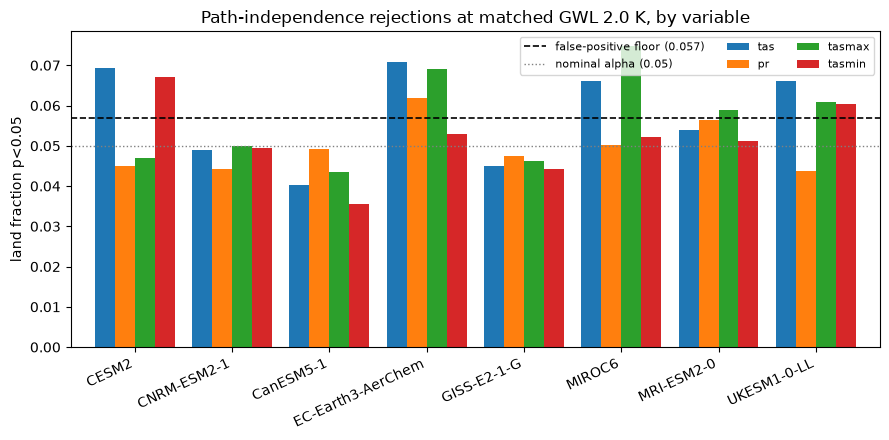

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
t3.drop(index='multi-model mean')[VARS].plot.bar(ax=ax, width=0.82)
ax.axhline(FLOOR, color='k', ls='--', lw=1.2, label=f'false-positive floor ({FLOOR})')
ax.axhline(ALPHA, color='0.5', ls=':', lw=1, label=f'nominal alpha ({ALPHA})')
ax.set_ylabel('land fraction p<0.05')
ax.set_xlabel('')
ax.set_title(f'Path-independence rejections at matched GWL {GWL} K, by variable')
ax.legend(fontsize=8, ncol=3)
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
fig.tight_layout()
fig.savefig(out_dir + 'summary_fig2_landfrac_vars.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'summary_fig2_landfrac_vars.png')

## Table 4 — every comparison family on one scale

Same statistic, three questions: does the *aerosol pathway* matter at fixed GWL (RAMIP), does the
*emissions scenario* matter (ScenarioMIP pairs), does the *direction of travel* matter (overshoot
up- vs down-crossing). Written only if `ks_location_scenarios.ipynb` has finished.

In [7]:
if not glob.glob(SCEN_KS + '*.nc'):
    print('scenario/overshoot caches not present yet — rerun this cell after '
          'ks_location_scenarios.ipynb finishes')
else:
    rows = []
    for fn in sorted(glob.glob(SCEN_KS + '*.nc')):
        name = os.path.basename(fn)[:-3]
        var = name.rsplit('_', 1)[-1]
        tag = name[:-(len(var) + 1)]
        fam = ('overshoot' if tag.startswith('over_') else
               'ramip' if tag.startswith('ramip_') else 'scenario')
        ds = xr.open_dataset(fn).load()
        rows.append({'family': fam, 'comparison': tag, 'var': var,
                     'n_pairs': ds.sizes['pair'], 'land_frac': kt.land_fraction(ds, 'pair', ALPHA)})
    t4 = pd.DataFrame(rows)
    t4.to_csv(SUM_DIR + 'table4_families.csv', index=False)
    piv = t4.pivot_table(index=['family', 'comparison'], columns='var', values='land_frac')
    print(f'land fraction rejecting (floor {FLOOR})')
    print(piv.round(3).to_string())
    print('\nby family, mean over comparisons:')
    print(t4.groupby(['family', 'var']).land_frac.mean().unstack().round(3).to_string())

land fraction rejecting (floor 0.057)
var                                             pr    tas
family    comparison                                     
overshoot over_gwl2.0_GISS-E2-1-G            0.062  0.096
          over_gwl2.0_MIROC6                 0.031  0.032
          over_gwl2.0_MRI-ESM2-0             0.145  0.398
          over_gwl2.5_CNRM-ESM2-1            0.076  0.095
          over_gwl2.5_GISS-E2-1-G            0.069  0.061
          over_gwl2.5_MRI-ESM2-0             0.045  0.156
          over_gwl3.0_GISS-E2-1-G            0.034  0.044
ramip     ramip_gwl1.5_CESM2                 0.039  0.051
          ramip_gwl1.5_CNRM-ESM2-1           0.050  0.055
          ramip_gwl1.5_CanESM5-1             0.054  0.041
          ramip_gwl1.5_EC-Earth3-AerChem     0.052  0.048
          ramip_gwl1.5_GISS-E2-1-G           0.033  0.047
          ramip_gwl1.5_MIROC6                0.040  0.072
          ramip_gwl1.5_MRI-ESM2-0            0.049  0.064
          ramip_gwl1.5_NorESM2-LM 

## Figure 3 — regional responses that GWL matching does *not* remove

The statistical tests ask whether the local *distribution* differs. This asks the blunter
question: how big is the mean response, per AR6 land region, at matched GWL2.0? A response that
is physically real but small compared with a decade of internal variability will show here and
still not reject above the floor — which is the main interpretive caveat of the whole analysis.

largest regional temperature responses:
          dtas_K  dpr_mm_day
GLB-land   1.952       0.144
EAN       -0.711      -0.043
ECA        0.522      -0.042
RFE        0.488       0.079
EEU        0.386      -0.009
EAS        0.384       0.131
GIC       -0.355      -0.037
WSB        0.266       0.007
NEN        0.265       0.043
TIB        0.265       0.166


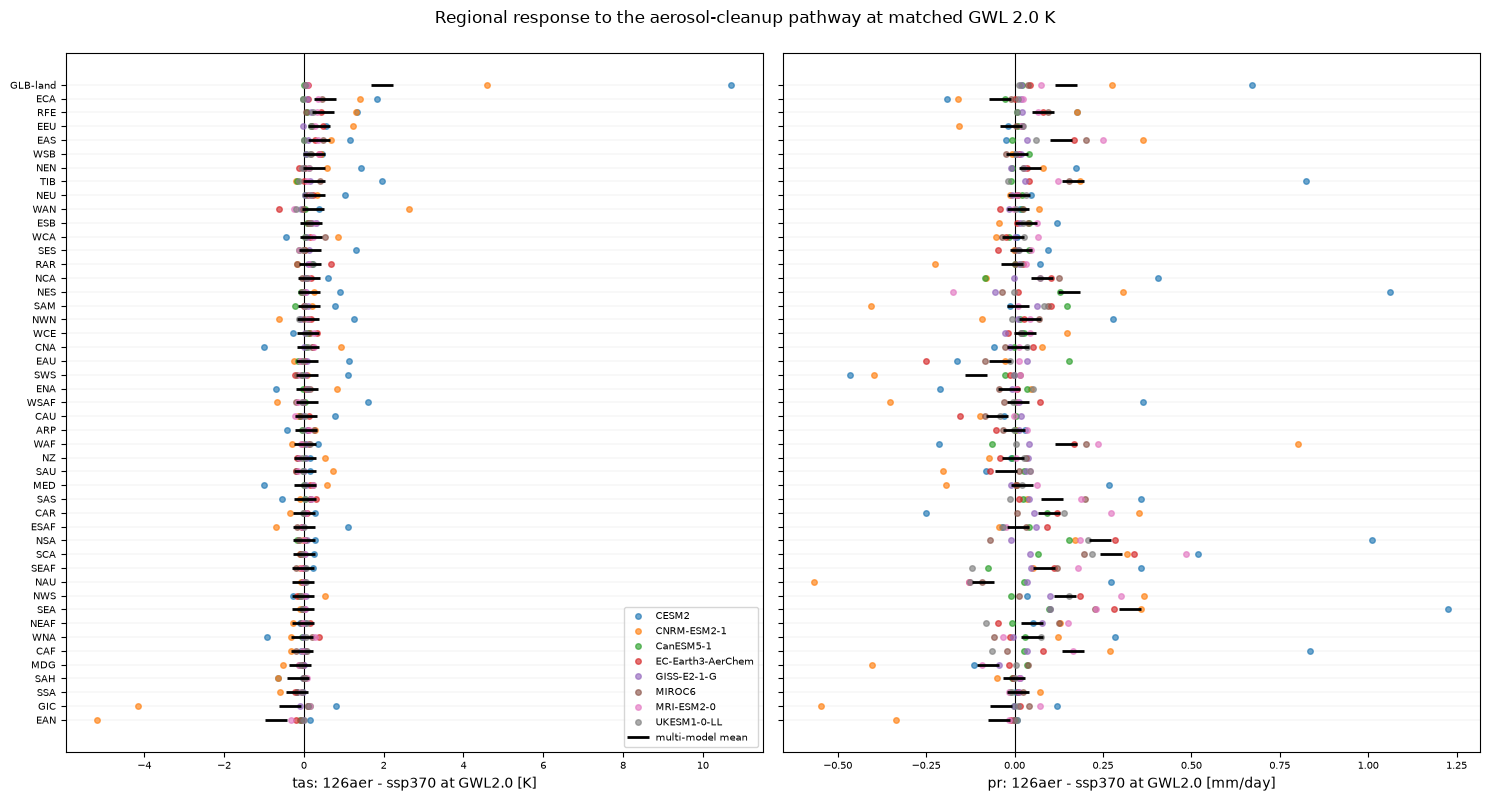

In [8]:
def gwl_slice(var, mod, exp, ends):
    """regional annual means over each run's own GWL window; ends maps run -> window end"""
    da = xr.open_dataset(f'{REG_DIR}{var}_{mod}.nc')[var].sel(exp=exp)
    keep = []
    for run, end in ends.items():
        if run not in da.run:
            continue
        s = da.sel(run=run, year=slice(end - 9, end))
        if s.year.size == 10 and np.isfinite(s).all():
            keep.append(s.mean('year'))
    return xr.concat(keep, dim='run').mean('run') if keep else None


win = pd.read_csv(f'{GWL_DIR}gwl{GWL}_windows.csv')
win = win[win.usable]
resp = {}
for var in ['tas', 'pr']:
    per_mod = []
    for mod in sorted(win.model.unique()):
        w = win[win.model == mod]
        a = gwl_slice(var, mod, anchor(mod), dict(zip(w.run, w.anchor_end.astype(int))))
        b = gwl_slice(var, mod, OTHER, dict(zip(w.run, w.other_end.astype(int))))
        if a is None or b is None:
            print(f'{var} {mod}: no complete windows, skipped')
            continue
        per_mod.append((b - a).assign_coords(model=mod))
    resp[var] = xr.concat(per_mod, dim='model')

ar6 = regionmask.defined_regions.ar6.land
abbrev = {int(r): ar6.abbrevs[int(r)] for r in resp['tas'].region.values if int(r) >= 0}
abbrev[-1] = 'GLB-land'

fig, axs = plt.subplots(1, 2, figsize=(15, 8), sharey=True)
for ax, (var, unit, scale) in zip(axs, [('tas', 'K', 1.0), ('pr', 'mm/day', 86400.0)]):
    d = (resp[var] * scale).to_pandas().T
    d.index = [abbrev[int(i)] for i in d.index]
    d = d.loc[d.mean(axis=1).sort_values().index]
    ax.axvline(0, color='k', lw=0.8)
    for mod in d.columns:
        ax.plot(d[mod], d.index, 'o', ms=4, alpha=0.65, label=mod)
    ax.plot(d.mean(axis=1), d.index, 'k_', ms=16, mew=2, label='multi-model mean')
    ax.set_xlabel(f'{var}: 126aer - ssp370 at GWL{GWL} [{unit}]')
    ax.tick_params(labelsize=7)
    ax.grid(axis='y', lw=0.3, alpha=0.4)
axs[0].legend(fontsize=7, loc='lower right')
fig.suptitle(f'Regional response to the aerosol-cleanup pathway at matched GWL {GWL} K', y=0.995)
fig.tight_layout()
fig.savefig(out_dir + 'summary_fig3_regional_response.png', dpi=150, bbox_inches='tight')

reg_tab = pd.concat({v: (resp[v] * (86400.0 if v == 'pr' else 1.0)).to_pandas().T.mean(axis=1)
                     for v in ['tas', 'pr']}, axis=1)
reg_tab.index = [abbrev[int(i)] for i in reg_tab.index]
reg_tab.columns = ['dtas_K', 'dpr_mm_day']
reg_tab.sort_values('dtas_K').to_csv(SUM_DIR + 'table5_regional_response.csv')
print('largest regional temperature responses:')
print(reg_tab.reindex(reg_tab.dtas_K.abs().sort_values(ascending=False).index).head(10).round(3))

## Figure 4 — the summary panel

Left: multi-model mean ΔT at matched GWL2.0 with stippling where fewer than 6 of 8 models agree
on sign. Right: the fraction of runs rejecting per pixel for `tas` — expected value 0.05
everywhere under path-independence, whatever the ensemble size (unlike a q01 map, which darkens
as runs are added).

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/summary_fig4_panel.png


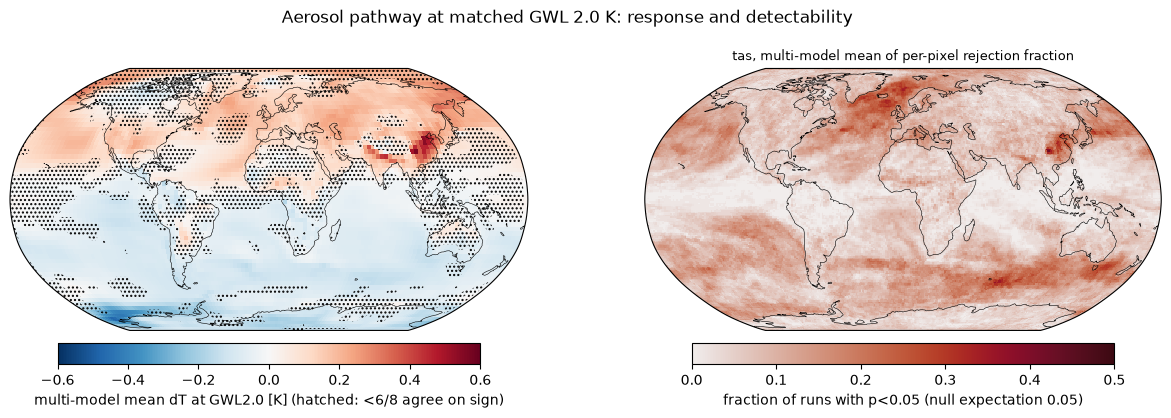

In [9]:
ks_files = sorted(glob.glob(f'{GWL_DIR}ks/*.nc'))
ref = xr.open_dataset(ks_files[0])
fr = []
for fn in ks_files:
    ds = xr.open_dataset(fn).load()
    f = (ds.p_blockperm < ALPHA).mean('run')
    fr.append(f if f.sizes == ref.sizes else f.interp(lat=ref.lat, lon=ref.lon))
frac = xr.concat(fr, dim='model').mean('model')

imp_fn = IMP_DIR + f'burke_gwl{GWL}.nc'
fig, axs = plt.subplots(1, 2, figsize=(15, 4.2), subplot_kw={'projection': ccrs.Robinson()})
if os.path.exists(imp_fn):
    imp = xr.open_dataset(imp_fn).load()
    dt = imp.dt.mean('run')
    agree = (np.sign(dt) == np.sign(dt.mean('model'))).sum('model')
    im0 = axs[0].pcolormesh(dt.lon, dt.lat, dt.mean('model'), cmap='RdBu_r', vmin=-0.6, vmax=0.6,
                            transform=ccrs.PlateCarree())
    lo = agree < 6
    axs[0].contourf(dt.lon, dt.lat, lo, levels=[0.5, 1.5], colors='none', hatches=['....'],
                    transform=ccrs.PlateCarree())
    plt.colorbar(im0, ax=axs[0], orientation='horizontal', pad=0.04, shrink=0.8,
                 label=f'multi-model mean dT at GWL{GWL} [K] (hatched: <6/8 agree on sign)')
else:
    axs[0].set_visible(False)
im1 = axs[1].pcolormesh(frac.lon, frac.lat, frac, cmap=cmocean.cm.amp, vmin=0, vmax=0.5,
                        transform=ccrs.PlateCarree())
plt.colorbar(im1, ax=axs[1], orientation='horizontal', pad=0.04, shrink=0.8,
             label=f'fraction of runs with p<{ALPHA} (null expectation {ALPHA})')
for ax in axs:
    if ax.get_visible():
        ax.coastlines(lw=0.4)
axs[1].set_title('tas, multi-model mean of per-pixel rejection fraction', fontsize=9)
fig.suptitle(f'Aerosol pathway at matched GWL {GWL} K: response and detectability', y=1.02)
fig.savefig(out_dir + 'summary_fig4_panel.png', dpi=150, bbox_inches='tight')
print('saved', out_dir + 'summary_fig4_panel.png')

## The overall picture

In [10]:
print(f'GWL{GWL}-matched land rejection fractions (test floor {FLOOR}):')
for var in VARS:
    v = t3.loc['multi-model mean', var]
    print(f'  {var:7s} {v:.3f}   {"at/below floor" if v <= FLOOR else "above floor"}')

lead = t2.lead_yr.dropna()
print(f'\naerosol cleanup reaches a given GWL {lead.mean():.1f} yr earlier on average '
      f'(range {lead.min():.1f}-{lead.max():.1f} yr) -- this is what year-matching confounded')

if os.path.exists(imp_fn):
    land = xr.DataArray(kt.land_mask(imp.lat.values, imp.lon.values),
                        coords={'lat': imp.lat, 'lon': imp.lon}, dims=('lat', 'lon'))
    lw = land * np.cos(np.deg2rad(imp.lat))
    sig = imp.dg.mean(('run', 'model'))
    tot = np.sqrt(imp.dg.mean('run').var('model') + imp.dg.var('run').mean('model'))
    print(f'\nBurke growth response: land-mean |signal| '
          f'{float(abs(sig).weighted(lw).mean(("lat", "lon"))):.5f}, '
          f'total sd {float(tot.weighted(lw).mean(("lat", "lon"))):.5f}; '
          f'signal exceeds sd on {float((abs(sig) > tot).where(land).sum() / land.sum()):.3f} '
          f'of land')

GWL2.0-matched land rejection fractions (test floor 0.057):
  tas     0.058   above floor
  pr      0.050   at/below floor
  tasmax  0.056   at/below floor
  tasmin  0.052   at/below floor

aerosol cleanup reaches a given GWL 6.5 yr earlier on average (range 0.0-14.5 yr) -- this is what year-matching confounded

Burke growth response: land-mean |signal| 0.00138, total sd 0.00513; signal exceeds sd on 0.007 of land


/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)
